In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Custom functions
import FockSystem.FockSystem as fst

from importlib import reload

In [2]:
%load_ext autoreload
%autoreload 2

# Constructing operator sequences

## Defining sequences

<span style="font-size:20px; font-weight:bold;">Identity and Zero</span>

In [3]:
## An empty initalization amounts to an operator that is zero
Zero = fst.OperSequence()
Zero

$\hat{0}$

In [4]:
## Build in alias
fst.Zero

$\hat{0}$

In [5]:
## Passing a single int always creates identity, regardless of the int
One = fst.OperSequence(1)
One

 $\hat{I}$

In [6]:
## Build in alias
fst.I

 $\hat{I}$

In [7]:
## Build in alias
fst.eye

 $\hat{I}$

## Basic Units

In [74]:
## A shortcut for creating the 4 basic operators are included, which will act one site 0
c_up = fst.c_up
c_down = fst.c_down
a_up = fst.a_up
a_down = fst.a_down

In [75]:
c_up

 $c^{†}_{0,↑}$

<span style="font-size:20px; font-weight:bold;">From Lists</span>


In [76]:
## The presentation of operators sequences are just lists of integers, can straight away create these by passing lists
## Since its not transparant which integer is which operator, also added other options below

In [77]:
fst.OperSequence([1],[2])

 $c_{0,↓}$ $+$ $c^{†}_{0,↑}$

In [78]:
fst.OperSequence([0,1],[1,2])

 $c^{†}_{0,↓}$$c_{0,↓}$ $+$ $c_{0,↓}$$c^{†}_{0,↑}$

<span style="font-size:20px; font-weight:bold;">From Tuples</span>


In [82]:
## The tuple method is a bit more insighful: tuple contains (creation/annilation, site, up/down)

In [83]:
fst.OperSequence((('c',0,'up'),('c',1,'down')), ('c',0,'down'), ('a',2,'up'))

 $c^{†}_{0,↑}$$c^{†}_{1,↓}$ $+$ $c^{†}_{0,↓}$ $+$ $c_{2,↑}$

<span style="font-size:20px; font-weight:bold;">From Strings</span>


In [86]:
## Following OpenFermion's convention, strings will be parsed in a (somewhat) similar manner
## I do not like this convention

In [98]:
fst.OperSequence('0^,1', '1^,0,2^')

 $c^{†}_{0,↓}$$c_{0,↑}$ $+$ $c^{†}_{0,↑}$$c_{0,↓}$$c^{†}_{1,↓}$

## Assigning weights

In [99]:
## Simplest way to set weights is just through multiplication

In [100]:
MU = 5*c_down*a_down
MU

 5.0j$c^{†}_{0,↓}$$c_{0,↓}$

In [101]:
## Weights can also be symbolic

import sympy as sp
mu = sp.Symbol('mu')

MU = mu*c_down*a_down
MU

 ($\displaystyle 1.0 i \mu$)$c^{†}_{0,↓}$$c_{0,↓}$

In [103]:
## The weights of operator sequences can be set also upon initialization
down = fst.OperSequence([0], weights = [1j])
up = fst.OperSequence([2], weights = [5])
op = down + up
op

 j$c^{†}_{0,↓}$ $+$ 5$c^{†}_{0,↑}$

In [104]:
## Can als use an OperSequence instance can be used to set the weight of that subsequence in a longer sequence
op = c_down + c_up
op[c_up] = 10
op[c_down] = 20
op

 20$c^{†}_{0,↓}$ $+$ 10$c^{†}_{0,↑}$

<span style="font-size:20px; font-weight:bold;">Shorthand code</span>


In [105]:
## The 'greater than' operator has additionally been reserved to quickly assign values

In [106]:
## Passing a single value assigns the same value to each subsequence
op = c_down + c_up
op > 3
op

 3$c^{†}_{0,↓}$ $+$ 3$c^{†}_{0,↑}$

In [107]:
## Passing an array assigns the values in order
op = c_down + c_up
op > [5,2]

 5$c^{†}_{0,↓}$ $+$ 2$c^{†}_{0,↑}$

# Supported Operator methods

## Basic operations

<span style="font-size:20px; font-weight:bold;">Addition and Subtraction</span>


In [108]:
c_down = fst.OperSequence([0])
c_up = fst.OperSequence([2])

In [109]:
c_up - c_down + (~c_up) + -10j

 $c^{†}_{0,↑}$ $-$ $c^{†}_{0,↓}$ $+$ $c_{0,↑}$ $-$ 10.0j$\hat{I}$

<span style="font-size:20px; font-weight:bold;">Multiplication and Division</span>


In [110]:
4*c_down*c_up

 4$c^{†}_{0,↓}$$c^{†}_{0,↑}$

In [111]:
## Normal ordering is automatically applied for multiplication
4*c_up*c_down

 $-$ 4$c^{†}_{0,↓}$$c^{†}_{0,↑}$

<span style="font-size:20px; font-weight:bold;">Exponentation</span>


In [112]:
## Test case: Creating an operator t from some paper that should give t**4 = 1
an, cr, up, dwn = "a", "c", "u", "d"
weights = [-1j, -1, 1, -1, 1j, -1j]
operators = [
    ((an, 0, up),(cr, 0, up), (an, 0, dwn)),
    ((an, 0, dwn), (cr, 0, dwn),(cr, 0, up)),
    (an, 0, up),
    ((an, 0, dwn),(cr, 0, dwn), (an, 0, up)),
    (cr, 0, dwn),
    ((an, 0, up),(cr, 0, up), (cr, 0, dwn)),
]
t = fst.OperSequence(*operators, weights=weights)

In [113]:
t

 $-$ j$c_{0,↑}$$c^{†}_{0,↑}$$c_{0,↓}$ $-$ $c_{0,↓}$$c^{†}_{0,↓}$$c^{†}_{0,↑}$ $+$ $c_{0,↑}$ $-$ $c_{0,↓}$$c^{†}_{0,↓}$$c_{0,↑}$ $+$ j$c^{†}_{0,↓}$ $-$ j$c_{0,↑}$$c^{†}_{0,↑}$$c^{†}_{0,↓}$

In [114]:
t**2

 j$c^{†}_{0,↑}$$c_{0,↓}$ $-$ j$c_{0,↓}$$c_{0,↑}$ $-$ j$c^{†}_{0,↓}$$c^{†}_{0,↑}$ $-$ j$c^{†}_{0,↓}$$c_{0,↑}$

In [115]:
t**3

 j$c^{†}_{0,↑}$$c_{0,↓}$$c_{0,↑}$ $-$ $c_{0,↑}$ $-$ $c^{†}_{0,↓}$$c^{†}_{0,↑}$$c_{0,↓}$ $-$ j$c^{†}_{0,↓}$$c^{†}_{0,↑}$$c_{0,↑}$ $+$ $c^{†}_{0,↓}$$c_{0,↓}$$c_{0,↑}$ $+$ j$c^{†}_{0,↓}$

In [116]:
t**4

 $\hat{I}$

## Additional Operations

<span style="font-size:20px; font-weight:bold;">Site shifting</span>


In [117]:
## The lshift and rshift operators will shift the entire sequence by the specified numbers of site

In [118]:
c_down = fst.OperSequence([0])
c_down >> 6

 $c^{†}_{6,↓}$

In [119]:
c_down = fst.OperSequence(('c',5,'down'))
c_down << 4

 $c^{†}_{1,↓}$

In [120]:
H_base = c_up*(~c_up) + c_up*(~c_up>>1)
H_base

 $c^{†}_{0,↑}$$c_{0,↑}$ $+$ $c^{†}_{0,↑}$$c_{1,↑}$

In [121]:
## Shift over an array of numbers
N = 3
H = H_base >> np.arange(1,N)
H

 $c^{†}_{0,↑}$$c_{0,↑}$ $+$ $c^{†}_{0,↑}$$c_{1,↑}$ $+$ $c^{†}_{1,↑}$$c_{1,↑}$ $+$ $c^{†}_{1,↑}$$c_{2,↑}$ $+$ $c^{†}_{2,↑}$$c_{2,↑}$ $+$ $c^{†}_{2,↑}$$c_{3,↑}$

<span style="font-size:20px; font-weight:bold;">Conjugation</span>


In [122]:
arbitrary_sequence = fst.OperSequence([0,1],[4,12],[3,11],[5,6,7])
arbitrary_sequence

 $c^{†}_{0,↓}$$c_{0,↓}$ $+$ $c^{†}_{1,↓}$$c^{†}_{3,↓}$ $+$ $c_{0,↑}$$c_{2,↑}$ $+$ $c_{1,↓}$$c^{†}_{1,↑}$$c_{1,↑}$

In [123]:
## Arbitraty sequence conjugated:
~arbitrary_sequence

 $c^{†}_{0,↓}$$c_{0,↓}$ $+$ $c_{3,↓}$$c_{1,↓}$ $+$ $c^{†}_{2,↑}$$c^{†}_{0,↑}$ $+$ $c^{†}_{1,↑}$$c_{1,↑}$$c^{†}_{1,↓}$

In [124]:
## TODO: add aliases for the conjugation instead of only the symbolic shortcut

<span style="font-size:20px; font-weight:bold;">Normal Ordering</span>


In [125]:
## Create example
example_seq = fst.OperSequence([1,0],[5,6,7])
example_seq

 $c_{0,↓}$$c^{†}_{0,↓}$ $+$ $c_{1,↓}$$c^{†}_{1,↑}$$c_{1,↑}$

In [127]:
## Normal order the example
example_seq.normal_order()
example_seq

 $-$ $c^{†}_{1,↑}$$c_{1,↓}$$c_{1,↑}$ $-$ $c^{†}_{0,↓}$$c_{0,↓}$ $+$ $\hat{I}$

<span style="font-size:20px; font-weight:bold;">Commutators</span>


In [130]:
c_up = fst.c_up
c_down = fst.c_down
c_down.commute(c_up)

 2$c^{†}_{0,↓}$$c^{†}_{0,↑}$

In [131]:
c_up = fst.c_up
c_down = fst.c_down
c_down.anticommute(c_up)

$\hat{0}$

# Connecting to Fock states

In [137]:
## The Fock State Class is interpreted by the OperSequence class to generate the data that represents a Hamiltonian
## TODO: Fix visualization of the states


In [138]:
## Create by passing number of Fermionic sites
basis = fst.FockStates(3)
basis

  |0,0,0〉+ |↓,0,0〉+ |↑,0,0〉+ |↓↑,0,0〉+ |0,↓,0〉$\cdots$ + |↓↑,↑,↓↑〉+ |0,↓↑,↓↑〉+ |↓,↓↑,↓↑〉+ |↑,↓↑,↓↑〉+ |↓↑,↓↑,↓↑〉

In [139]:
## Create by passing array of ints that represent specific states
basis = fst.FockStates([0,1,2,5,8])
basis

 + |0,0〉+ |↓,0〉+ |↑,0〉+ |↓,↓〉+ |0,↑〉

<span style="font-size:20px; font-weight:bold;">Restricting the Fock Space</span>


In [140]:
basis = fst.FockStates(3)
even_states = basis.restrict(parity='even')
even_states

 + |0,0,0〉+ |↓↑,0,0〉+ |↓,↓,0〉+ |↑,↓,0〉+ |↓,↑,0〉+ |↑,↑,0〉+ |0,↓↑,0〉+ |↓↑,↓↑,0〉+ |↓,0,↓〉+ |↑,0,↓〉+ |0,↓,↓〉+ |↓↑,↓,↓〉+ |0,↑,↓〉+ |↓↑,↑,↓〉+ |↓,↓↑,↓〉+ |↑,↓↑,↓〉+ |↓,0,↑〉+ |↑,0,↑〉+ |0,↓,↑〉+ |↓↑,↓,↑〉+ |0,↑,↑〉+ |↓↑,↑,↑〉+ |↓,↓↑,↑〉+ |↑,↓↑,↑〉+ |0,0,↓↑〉+ |↓↑,0,↓↑〉+ |↓,↓,↓↑〉+ |↑,↓,↓↑〉+ |↓,↑,↓↑〉+ |↑,↑,↓↑〉+ |0,↓↑,↓↑〉+ |↓↑,↓↑,↓↑〉

In [141]:
basis = fst.FockStates(3)
only_spin_down = basis.restrict(Ez_inf=True,U_inf=True)
only_spin_down

 + |0,0,0〉+ |↓,0,0〉+ |0,↓,0〉+ |↓,↓,0〉+ |0,0,↓〉+ |↓,0,↓〉+ |0,↓,↓〉+ |↓,↓,↓〉

<span style="font-size:20px; font-weight:bold;">Calculating Hamiltonian action on a basis</span>


In [142]:
## Define basic elements for convenience
c_down = fst.OperSequence([0])
c_up = fst.OperSequence([2])
a_up = ~c_up
a_down = ~c_down

## Construct basic Hamiltonian
H = c_down*a_down + 20*c_down*(c_down >>1) + 20*c_down*(a_down>>1)
H

 $c^{†}_{0,↓}$$c_{0,↓}$ $+$ 20$c^{†}_{0,↓}$$c^{†}_{1,↓}$ $+$ 20$c^{†}_{0,↓}$$c_{1,↓}$

In [143]:
## Define basis
basis = fst.FockStates(3)
only_spin_down_basis = basis.restrict(Ez_inf=True,U_inf=True)
only_spin_down_basis

 + |0,0,0〉+ |↓,0,0〉+ |0,↓,0〉+ |↓,↓,0〉+ |0,0,↓〉+ |↓,0,↓〉+ |0,↓,↓〉+ |↓,↓,↓〉

In [146]:
## Convert to array or sparse object
H_data = H[only_spin_down_basis]
H_as_array = H_data.to_array()
H_sparse_coo = H_data.to_sparse_coo()
H_sparse_csr = H_data.to_sparse_csr()

<span style="font-size:20px; font-weight:bold;">Block diagonalization</span>


In [147]:
## The function .to_block_diagonal_basis() is provided to return a new FockStates instance that has been ordered to be block diagonal in the coupled OperSequence

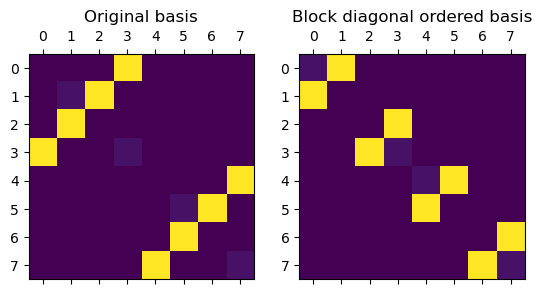

In [148]:
bd_basis = H[only_spin_down_basis].to_block_diagonal_basis()
fig,axs = plt.subplots(ncols = 2)
axs[0].set_title("Original basis")
axs[0].matshow(np.real(H[only_spin_down].to_array()))
axs[1].set_title("Block diagonal ordered basis")
axs[1].matshow(np.real(H[bd_basis].to_array()))

<span style="font-size:20px; font-weight:bold;">Matrix-Vector Multiplication</span>


In [ ]:
## Matrix vector product has been implemented, so that one does not have to go to the SCIPY CSR class
## Instead a scipy.LinearOperator can be defined

In [149]:
random_vector = np.array([np.random.randint(10) for _ in  range(len(only_spin_down_basis.states))], dtype=complex)

## The @ symbol implements matrix-vecotr multipliction of OperSequence in a selected basis
print("Direct matrix-vector product")
result = H[only_spin_down] @ random_vector
print(np.array(result))

## This is identical to converting first to an array and handling the matrix-vector product there
## The direct method becomes faster and less memory-intensive for larger systems (N > 5)
array = H[only_spin_down_basis].to_array()
print("Normal matrix-vector product")
result = array @ random_vector
print(result)

Direct matrix-vector product
[ 20.+0.j 102.+0.j  40.+0.j 181.+0.j   0.+0.j 123.+0.j  60.+0.j 120.+0.j]
Normal matrix-vector product
[ 20.+0.j 102.+0.j  40.+0.j 181.+0.j   0.+0.j 123.+0.j  60.+0.j 120.+0.j]


# Minimal Example - The effective kitaev chain


<span style="font-size:20px; font-weight:bold;">Constructing the Hamiltonian from scratch</span>


In [56]:
## Define basic elements for convenience
c_down = fst.OperSequence([0])
c_up = fst.OperSequence([2])
a_up = ~c_up
a_down = ~c_down

In [57]:
## Build components
ECT = c_down*(a_down>>1)
ECT

 $c^{†}_{0,↓}$$c_{1,↓}$

In [58]:
## Span components over a range
ECT >> np.arange(1,5)

 $c^{†}_{0,↓}$$c_{1,↓}$ $+$ $c^{†}_{1,↓}$$c_{2,↓}$ $+$ $c^{†}_{2,↓}$$c_{3,↓}$ $+$ $c^{†}_{3,↓}$$c_{4,↓}$ $+$ $c^{†}_{4,↓}$$c_{5,↓}$

In [59]:
## Build the Hamiltonian
## By building from subsequences, the value of individual terms can be easily accessed later
N = 3

ECT = c_down*(~c_down>>1)
ECT = ECT >> np.arange(1,N-1)
    
CAR = c_down*(c_down>>1)
CAR = CAR >> np.arange(1,N-1)

MU = c_down*(~c_down)
MU = MU >> np.arange(1,N)

H = MU + CAR +ECT
H

 $c^{†}_{0,↓}$$c_{0,↓}$ $+$ $c^{†}_{1,↓}$$c_{1,↓}$ $+$ $c^{†}_{2,↓}$$c_{2,↓}$ $+$ $c^{†}_{0,↓}$$c^{†}_{1,↓}$ $+$ $c^{†}_{1,↓}$$c^{†}_{2,↓}$ $+$ $c^{†}_{0,↓}$$c_{1,↓}$ $+$ $c^{†}_{1,↓}$$c_{2,↓}$

In [60]:
## Define a basis
basis = fst.FockStates(N)
basis = basis.restrict(Ez_inf=True,U_inf=True)

In [61]:
## Set values
H[ECT] = 5
H[CAR] = 10
H[MU[0]] = 6
H[MU[1]] = 7

In [62]:
H[basis].to_array()

array([[ 0.+0.j,  0.+0.j,  0.+0.j, 10.+0.j,  0.+0.j,  0.+0.j, 10.+0.j,
         0.+0.j],
       [ 0.+0.j,  6.+0.j,  5.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
        10.+0.j],
       [ 0.+0.j,  5.+0.j,  7.+0.j,  0.+0.j,  5.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [10.+0.j,  0.+0.j,  0.+0.j, 13.+0.j,  0.+0.j,  5.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  5.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,
        10.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  5.+0.j,  0.+0.j,  7.+0.j,  5.+0.j,
         0.+0.j],
       [10.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  5.+0.j,  8.+0.j,
         0.+0.j],
       [ 0.+0.j, 10.+0.j,  0.+0.j,  0.+0.j, 10.+0.j,  0.+0.j,  0.+0.j,
        14.+0.j]])

In [63]:
## Optional: Split basis into odd and even and restrict to inf U and inf Ez (i.e., exclude double occupation and spin-up occupation states)
even_basis = basis.restrict('even',Ez_inf=True,U_inf=True)
even_array = H[even_basis].to_array()
odd_basis = basis.restrict('odd',Ez_inf=True,U_inf=True)
odd_array = H[odd_basis].to_array()

<span style="font-size:20px; font-weight:bold;">Phase diagrams</span>


<span style="font-size:20px; font-weight:bold;">Pre-defined functions</span>


In [64]:
import Analysis.transport_tools as tu
from Analysis.systems import kitaev_chain

In [65]:
basis = fst.FockStates(3)
even_basis = basis.restrict('even',Ez_inf=True,U_inf=True)
even_array = H[even_basis].to_array()
odd_basis = basis.restrict('odd',Ez_inf=True,U_inf=True)
odd_array = H[odd_basis].to_array()

In [66]:
MU, ECT, CAR  = kitaev_chain(3)
H = MU  + ECT  + CAR
H[CAR] = 30

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 58.67it/s]


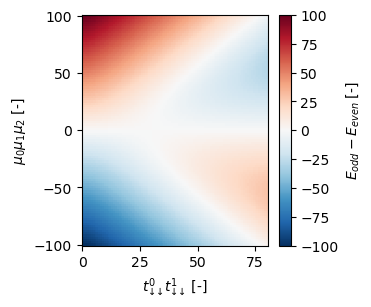

In [67]:
mu_range = np.linspace(-100,100,100)
t_range = np.linspace(0,80,100)

## Loop over range and get array, pass to linalg for eigenvalues
result = tu.phase_diagram(H,odd_basis,even_basis, ECT, t_range, MU, mu_range)

fig,ax = plt.subplots(ncols=1, figsize = (3,3))
result['E'].plot()

<span style="font-size:20px; font-weight:bold;">Conductance</span>


In [68]:
N = 4
MU,CAR,ECT = kitaev_chain(N)

H = MU + CAR + ECT

H[MU] = 0
H[CAR] = 20e-3
H[ECT] = 20e-3

basis = fst.FockStates(N).restrict(Ez_inf=True,U_inf=True)

In [69]:
lead_params = {"gammas": [0.001]*N, "kBT": 0.002, "dV": 0.001}
bias_range = np.linspace(-70e-3,70e-3, 100)
mu_range = np.linspace(-50e-3,50e-3,100)

In [70]:
Gs = tu.conductance_spectrum(H, basis, MU, mu_range, bias_range,sites = np.arange(N), lead_params = lead_params)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:23<00:00,  4.19it/s]


In [71]:
fig, axs = pplt.subplots(np.arange(1,N+1),figwidth=7)
fig.format(xlocator = 0.05,xminorlocator=0.025,ylocator = 0.05,yminorlocator=0.025)
axs.format(xlabel='$\\mu$',ylabel = '$V_{\\mathrm{bias}}$')
for i in range(len(axs)):
    im=axs[i].pcolormesh(mu_range,bias_range,Gs[f'G_{i}{i}'], cmap='magma')
    axs[i].colorbar(im,loc='top', length = 0.5, width=0.05,align='right')

NameError: name 'pplt' is not defined